<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_routed_memory_bus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

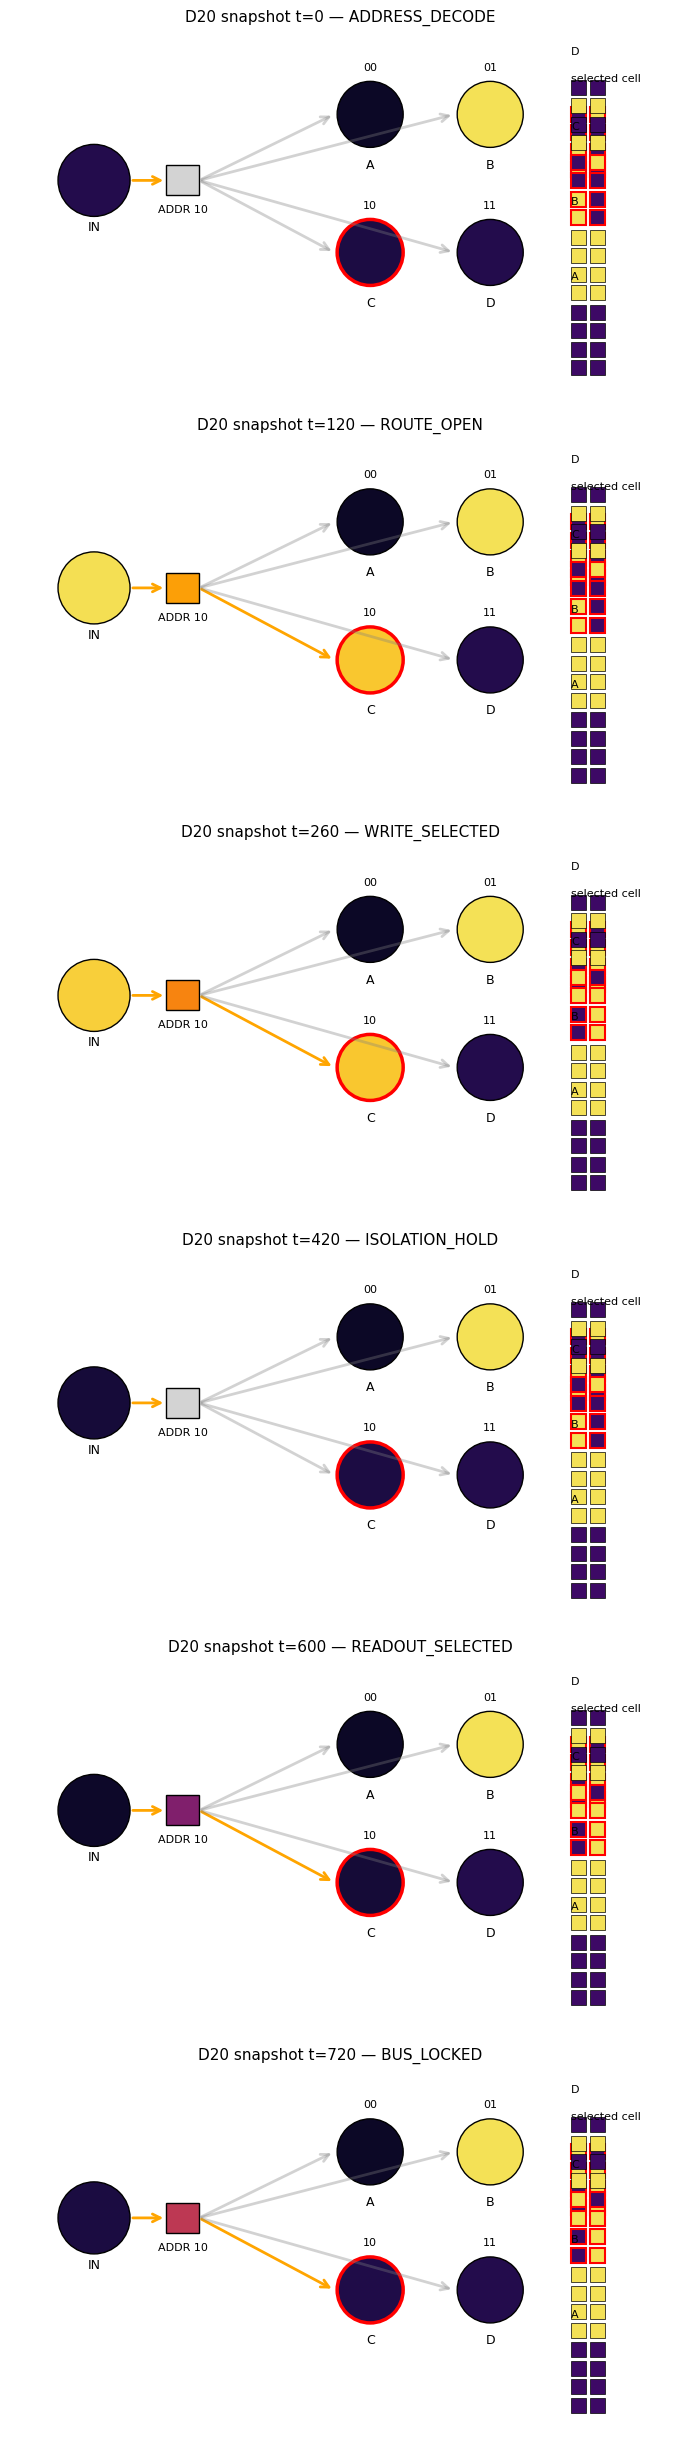

STATE: ROUTED_MEMORY_BUS_LOCKED
input sequence:       10110101
address bits:         10
decoded address:      10
selected cell:        MEM_CELL_C
written sequence:     10110101
readout sequence:     10110101
address locked:       True
write accuracy:       1.0
readout accuracy:     1.0
isolation accuracy:   1.0

Address decode table:


,STATE,ADDRESS_BIT_INDEX,INPUT_ADDRESS_BIT,RECEIVED_MEAN,DECODED_ADDRESS_BIT,MATCH
0,D20_ROUTED_MEMORY_BUS,0,1,0.771,1,1
1,D20_ROUTED_MEMORY_BUS,1,0,0.217,0,1



Selected-cell write table:


,STATE,MEMORY_SLOT,INPUT_BIT,BEFORE_BIT,AFTER_BIT,WRITTEN,CHANGED
0,D20_ROUTED_MEMORY_BUS,0,1,0,1,1,1
1,D20_ROUTED_MEMORY_BUS,1,0,1,0,1,1
2,D20_ROUTED_MEMORY_BUS,2,1,0,1,1,1
3,D20_ROUTED_MEMORY_BUS,3,1,0,1,1,1
4,D20_ROUTED_MEMORY_BUS,4,0,1,0,1,1
5,D20_ROUTED_MEMORY_BUS,5,1,0,1,1,1
6,D20_ROUTED_MEMORY_BUS,6,0,1,0,1,1
7,D20_ROUTED_MEMORY_BUS,7,1,0,1,1,1



Memory isolation table:


,STATE,CELL,ADDRESS,SELECTED,BEFORE_SEQUENCE,AFTER_SEQUENCE,EXPECTED_AFTER,UNCHANGED_IF_NOT_SELECTED,MATCH
0,D20_ROUTED_MEMORY_BUS,MEM_CELL_A,00,0,00000000,00000000,00000000,1,1
1,D20_ROUTED_MEMORY_BUS,MEM_CELL_B,01,0,11111111,11111111,11111111,1,1
2,D20_ROUTED_MEMORY_BUS,MEM_CELL_C,10,1,01001010,10110101,10110101,target_written,1
3,D20_ROUTED_MEMORY_BUS,MEM_CELL_D,11,0,00110011,00110011,00110011,1,1



Summary:


,STATE,RESULT,INPUT_SEQUENCE,ADDRESS_BITS,DECODED_ADDRESS,SELECTED_CELL,WRITTEN_SEQUENCE,READOUT_SEQUENCE,ADDRESS_LOCKED,WRITE_ACCURACY,READOUT_ACCURACY,ISOLATION_ACCURACY,DECODE_THRESHOLD
0,D20_ROUTED_MEMORY_BUS,ROUTED_MEMORY_BUS_LOCKED,10110101,10,10,MEM_CELL_C,10110101,10110101,1,1.0,1.0,1.0,0.5


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch

# ============================================================
# D20_ROUTED_MEMORY_BUS
# Addressed field memory routing
#
# Goal:
# input sequence
# -> address decode
# -> route open to selected memory cell
# -> write only selected cell
# -> verify isolation of all other cells
# -> read back selected memory
# ============================================================

np.random.seed(20)

STATE = "D20_ROUTED_MEMORY_BUS"

input_sequence = "10110101"
address_bits = "10"
decode_threshold = 0.50

address_map = {
    "00": "MEM_CELL_A",
    "01": "MEM_CELL_B",
    "10": "MEM_CELL_C",
    "11": "MEM_CELL_D",
}

memory_before = {
    "MEM_CELL_A": "00000000",
    "MEM_CELL_B": "11111111",
    "MEM_CELL_C": "01001010",
    "MEM_CELL_D": "00110011",
}

selected_cell_expected = address_map[address_bits]


def bits_to_string(bits):
    return "".join(str(int(x)) for x in bits)


def seq_to_bits(seq):
    return [int(x) for x in seq]


def accuracy(a, b):
    return float(np.mean(np.array(seq_to_bits(a)) == np.array(seq_to_bits(b))))


# ------------------------------------------------------------
# Address decode
# ------------------------------------------------------------

address_received = []
for bit in address_bits:
    if bit == "1":
        value = 0.74 + np.random.normal(0, 0.035)
    else:
        value = 0.21 + np.random.normal(0, 0.035)
    address_received.append(float(np.clip(value, 0.0, 1.0)))

decoded_address_bits = bits_to_string([1 if v >= decode_threshold else 0 for v in address_received])
selected_cell_decoded = address_map.get(decoded_address_bits, None)

address_locked = decoded_address_bits == address_bits
selected_cell = selected_cell_decoded if address_locked else None


# ------------------------------------------------------------
# Routed write
# ------------------------------------------------------------

memory_after = memory_before.copy()

if selected_cell is not None:
    memory_after[selected_cell] = input_sequence

readout_sequence = memory_after[selected_cell] if selected_cell is not None else "????????"

write_accuracy = accuracy(memory_after[selected_cell_expected], input_sequence)
readout_accuracy = accuracy(readout_sequence, input_sequence)

isolation_checks = []
for cell_name in memory_before:
    if cell_name == selected_cell_expected:
        unchanged = False
        expected_after = input_sequence
    else:
        unchanged = memory_after[cell_name] == memory_before[cell_name]
        expected_after = memory_before[cell_name]

    isolation_checks.append({
        "STATE": STATE,
        "CELL": cell_name,
        "ADDRESS": [k for k, v in address_map.items() if v == cell_name][0],
        "SELECTED": int(cell_name == selected_cell_expected),
        "BEFORE_SEQUENCE": memory_before[cell_name],
        "AFTER_SEQUENCE": memory_after[cell_name],
        "EXPECTED_AFTER": expected_after,
        "UNCHANGED_IF_NOT_SELECTED": int(unchanged) if cell_name != selected_cell_expected else "target_written",
        "MATCH": int(memory_after[cell_name] == expected_after)
    })

df_cells = pd.DataFrame(isolation_checks)

isolation_accuracy = float(np.mean([
    row["MATCH"] for row in isolation_checks
]))

route_rows = []
for i, bit in enumerate(address_bits):
    route_rows.append({
        "STATE": STATE,
        "ADDRESS_BIT_INDEX": i,
        "INPUT_ADDRESS_BIT": int(bit),
        "RECEIVED_MEAN": round(address_received[i], 3),
        "DECODED_ADDRESS_BIT": int(decoded_address_bits[i]),
        "MATCH": int(decoded_address_bits[i] == bit)
    })

df_route = pd.DataFrame(route_rows)

bit_rows = []
before_selected = memory_before[selected_cell_expected]
after_selected = memory_after[selected_cell_expected]

for i, bit in enumerate(input_sequence):
    bit_rows.append({
        "STATE": STATE,
        "MEMORY_SLOT": i,
        "INPUT_BIT": int(bit),
        "BEFORE_BIT": int(before_selected[i]),
        "AFTER_BIT": int(after_selected[i]),
        "WRITTEN": int(after_selected[i] == bit),
        "CHANGED": int(before_selected[i] != after_selected[i])
    })

df_bits = pd.DataFrame(bit_rows)

result = (
    "ROUTED_MEMORY_BUS_LOCKED"
    if address_locked and write_accuracy == 1.0 and readout_accuracy == 1.0 and isolation_accuracy == 1.0
    else "ROUTED_MEMORY_BUS_PARTIAL"
)

df_summary = pd.DataFrame([{
    "STATE": STATE,
    "RESULT": result,
    "INPUT_SEQUENCE": input_sequence,
    "ADDRESS_BITS": address_bits,
    "DECODED_ADDRESS": decoded_address_bits,
    "SELECTED_CELL": selected_cell_expected,
    "WRITTEN_SEQUENCE": memory_after[selected_cell_expected],
    "READOUT_SEQUENCE": readout_sequence,
    "ADDRESS_LOCKED": int(address_locked),
    "WRITE_ACCURACY": round(write_accuracy, 3),
    "READOUT_ACCURACY": round(readout_accuracy, 3),
    "ISOLATION_ACCURACY": round(isolation_accuracy, 3),
    "DECODE_THRESHOLD": decode_threshold
}])


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

def bit_color(bit, intensity=1.0):
    if bit == 1:
        return plt.cm.inferno(0.70 + 0.22 * intensity)
    return plt.cm.inferno(0.07 + 0.12 * intensity)


cell_positions = {
    "MEM_CELL_A": (6.0, 6.0),
    "MEM_CELL_B": (8.0, 6.0),
    "MEM_CELL_C": (6.0, 3.7),
    "MEM_CELL_D": (8.0, 3.7),
}

address_labels = {
    "MEM_CELL_A": "00",
    "MEM_CELL_B": "01",
    "MEM_CELL_C": "10",
    "MEM_CELL_D": "11",
}


def draw_bit_grid(ax, x0, y0, seq, title, selected=False):
    bits = seq_to_bits(seq)
    cell = 0.25
    gap = 0.06

    ax.text(x0, y0 + 1.55, title, fontsize=8, ha="left", va="bottom", color="black")

    for i, bit in enumerate(bits):
        col = i % 2
        row = i // 2

        x = x0 + col * (cell + gap)
        y = y0 + (3 - row) * (cell + gap)

        edge = "red" if selected else "black"
        lw = 1.5 if selected else 0.5

        rect = Rectangle(
            (x, y),
            cell,
            cell,
            facecolor=bit_color(bit),
            edgecolor=edge,
            linewidth=lw
        )
        ax.add_patch(rect)


def draw_cell(ax, name, seq, active=False, selected=False, phase=0.0):
    x, y = cell_positions[name]
    bits = seq_to_bits(seq)
    mean_bit = np.mean(bits)

    pulse = 0.5 + 0.5 * np.sin(2 * np.pi * phase)
    visual_value = 0.35 * mean_bit + 0.65 * pulse if active else mean_bit

    color = bit_color(1 if visual_value > 0.5 else 0, visual_value)
    edge = "red" if selected else "black"
    lw = 2.5 if selected else 1.0

    ax.add_patch(Circle((x, y), 0.55, facecolor=color, edgecolor=edge, linewidth=lw))

    ax.text(x, y - 0.85, name[-1], fontsize=9, ha="center", va="center", color="black")
    ax.text(x, y + 0.78, address_labels[name], fontsize=8, ha="center", va="center", color="black")


def draw_arrow(ax, start, end, active=False):
    color = "orange" if active else "gray"
    alpha = 1.0 if active else 0.35

    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="->",
        mutation_scale=14,
        linewidth=2.0,
        color=color,
        alpha=alpha
    )
    ax.add_patch(arrow)


def draw_snapshot(ax, t, phase, stage):
    ax.set_facecolor("white")
    ax.set_xlim(0, 11)
    ax.set_ylim(1.2, 7.4)
    ax.set_aspect("equal")
    ax.axis("off")

    after_write = stage in ["WRITE_SELECTED", "READOUT_SELECTED", "BUS_LOCKED"]
    active_route = stage in ["ROUTE_OPEN", "WRITE_SELECTED", "READOUT_SELECTED", "BUS_LOCKED"]

    current_memory = memory_after if after_write else memory_before

    # Input signal cell
    input_pulse = 0.5 + 0.5 * np.sin(2 * np.pi * phase)
    input_bit = 1 if input_pulse > 0.5 else 0

    ax.add_patch(Circle(
        (1.4, 4.9),
        0.6,
        facecolor=bit_color(input_bit, input_pulse),
        edgecolor="black",
        linewidth=1.0
    ))
    ax.text(1.4, 4.05, "IN", fontsize=9, ha="center", color="black")

    # Address decoder / router
    router_color = plt.cm.inferno(0.35 + 0.45 * input_pulse) if active_route else "lightgray"
    ax.add_patch(Rectangle(
        (2.6, 4.65),
        0.55,
        0.5,
        facecolor=router_color,
        edgecolor="black",
        linewidth=1.0
    ))
    ax.text(2.88, 4.35, f"ADDR {decoded_address_bits}", fontsize=8, ha="center", color="black")

    draw_arrow(ax, (2.0, 4.9), (2.6, 4.9), active=True)

    # Memory cells
    for cell_name in memory_before:
        is_selected = cell_name == selected_cell_expected
        is_active = is_selected and active_route

        draw_cell(
            ax,
            cell_name,
            current_memory[cell_name],
            active=is_active,
            selected=is_selected,
            phase=phase
        )

    # Routes from router to memory cells
    for cell_name, pos in cell_positions.items():
        is_selected = cell_name == selected_cell_expected
        draw_arrow(ax, (3.15, 4.9), (pos[0] - 0.6, pos[1]), active=(is_selected and active_route))

    # Selected bank grid
    draw_bit_grid(
        ax,
        9.35,
        4.95,
        current_memory[selected_cell_expected],
        "selected cell",
        selected=True
    )

    # Full memory bank state
    y0 = 1.65
    for idx, cell_name in enumerate(memory_before):
        draw_bit_grid(
            ax,
            9.35,
            y0 + idx * 1.25,
            current_memory[cell_name],
            cell_name[-1],
            selected=(cell_name == selected_cell_expected)
        )

    ax.set_title(f"D20 snapshot t={t} — {stage}", fontsize=11, color="black")


snapshots = [
    (0, 0.00, "ADDRESS_DECODE"),
    (120, 0.20, "ROUTE_OPEN"),
    (260, 0.38, "WRITE_SELECTED"),
    (420, 0.58, "ISOLATION_HOLD"),
    (600, 0.78, "READOUT_SELECTED"),
    (720, 0.95, "BUS_LOCKED"),
]

fig, axes = plt.subplots(len(snapshots), 1, figsize=(7, 4.1 * len(snapshots)))

for ax, (t, phase, stage) in zip(axes, snapshots):
    draw_snapshot(ax, t, phase, stage)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

print(f"STATE: {result}")
print(f"input sequence:       {input_sequence}")
print(f"address bits:         {address_bits}")
print(f"decoded address:      {decoded_address_bits}")
print(f"selected cell:        {selected_cell_expected}")
print(f"written sequence:     {memory_after[selected_cell_expected]}")
print(f"readout sequence:     {readout_sequence}")
print(f"address locked:       {address_locked}")
print(f"write accuracy:       {round(write_accuracy, 3)}")
print(f"readout accuracy:     {round(readout_accuracy, 3)}")
print(f"isolation accuracy:   {round(isolation_accuracy, 3)}")

print("\nAddress decode table:")
display(df_route)

print("\nSelected-cell write table:")
display(df_bits)

print("\nMemory isolation table:")
display(df_cells)

print("\nSummary:")
display(df_summary)